<a href="https://colab.research.google.com/github/AichaELMouta/GiveMeSomeCreditClassification/blob/main/CreditClassificationML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We are developping a machine learning application to predict loan risk using the 'Give Me Some Credit' dataset from Kaggle.

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import Dataset

In [4]:
creditdata = pd.read_csv('cs-training.csv')

In [5]:
creditdata.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Data cleaning and Preparation

In [6]:
creditdata.columns


Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [7]:
creditdata.shape

(150000, 12)

In [42]:
if "Unnamed: 0" in creditdata.columns:
    creditdata = creditdata.drop(columns=["Unnamed: 0"])

In [8]:
creditdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [9]:
creditdata[creditdata.duplicated(keep=False)]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


In [10]:
creditdata.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [11]:
null_rows = creditdata[creditdata['MonthlyIncome'].isna()]
null_rows

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
6,7,0,0.305682,57,0,5710.0,NaN,8,0,3,0,0.0
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
16,17,0,0.061086,78,0,2058.0,NaN,10,0,2,0,0.0
32,33,0,0.083418,62,0,977.0,NaN,6,0,1,0,0.0
41,42,0,0.072898,81,0,75.0,NaN,7,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149976,149977,0,0.000627,76,0,60.0,NaN,5,0,0,0,0.0
149977,149978,0,0.236450,29,0,349.0,NaN,3,0,0,0,0.0
149984,149985,0,0.037548,84,0,25.0,NaN,5,0,0,0,0.0
149992,149993,0,0.871976,50,0,4132.0,NaN,11,0,1,0,3.0


In [12]:
null_rows_dependent = creditdata[creditdata['NumberOfDependents'].isna()]
null_rows_dependent

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
96,97,0,0.542243,48,2,10.0,NaN,2,0,0,0,NaN
109,110,0,0.041258,61,0,4739.0,NaN,11,0,4,0,NaN
159,160,0,0.000000,63,0,2.0,NaN,4,0,0,0,NaN
238,239,0,1.000000,28,0,0.0,NaN,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
149826,149827,0,0.027319,71,0,1419.0,NaN,13,0,1,0,NaN
149854,149855,0,0.056589,75,0,8.0,NaN,3,0,0,0,NaN
149894,149895,0,0.017904,55,0,1058.0,NaN,8,0,1,1,NaN
149948,149949,0,0.055530,27,0,10.0,NaN,1,0,0,0,NaN


In [13]:
creditdata['SeriousDlqin2yrs'].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


# Explatory Data Analysis

In [14]:
creditdata['SeriousDlqin2yrs'].value_counts(normalize=True)

,proportion
SeriousDlqin2yrs,
0,0.93316
1,0.06684


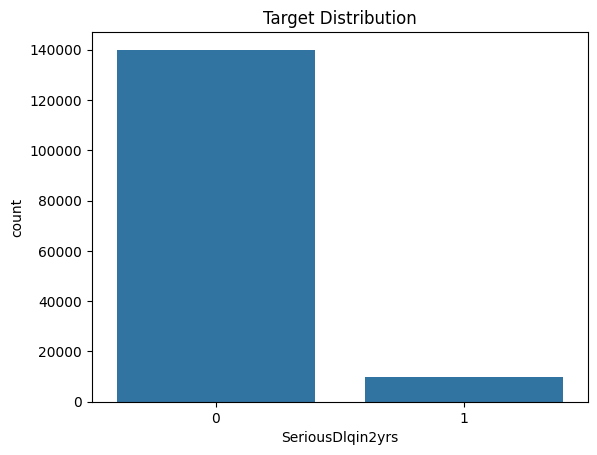

In [15]:
sns.countplot(x='SeriousDlqin2yrs', data=creditdata)
plt.title("Target Distribution")
plt.show()

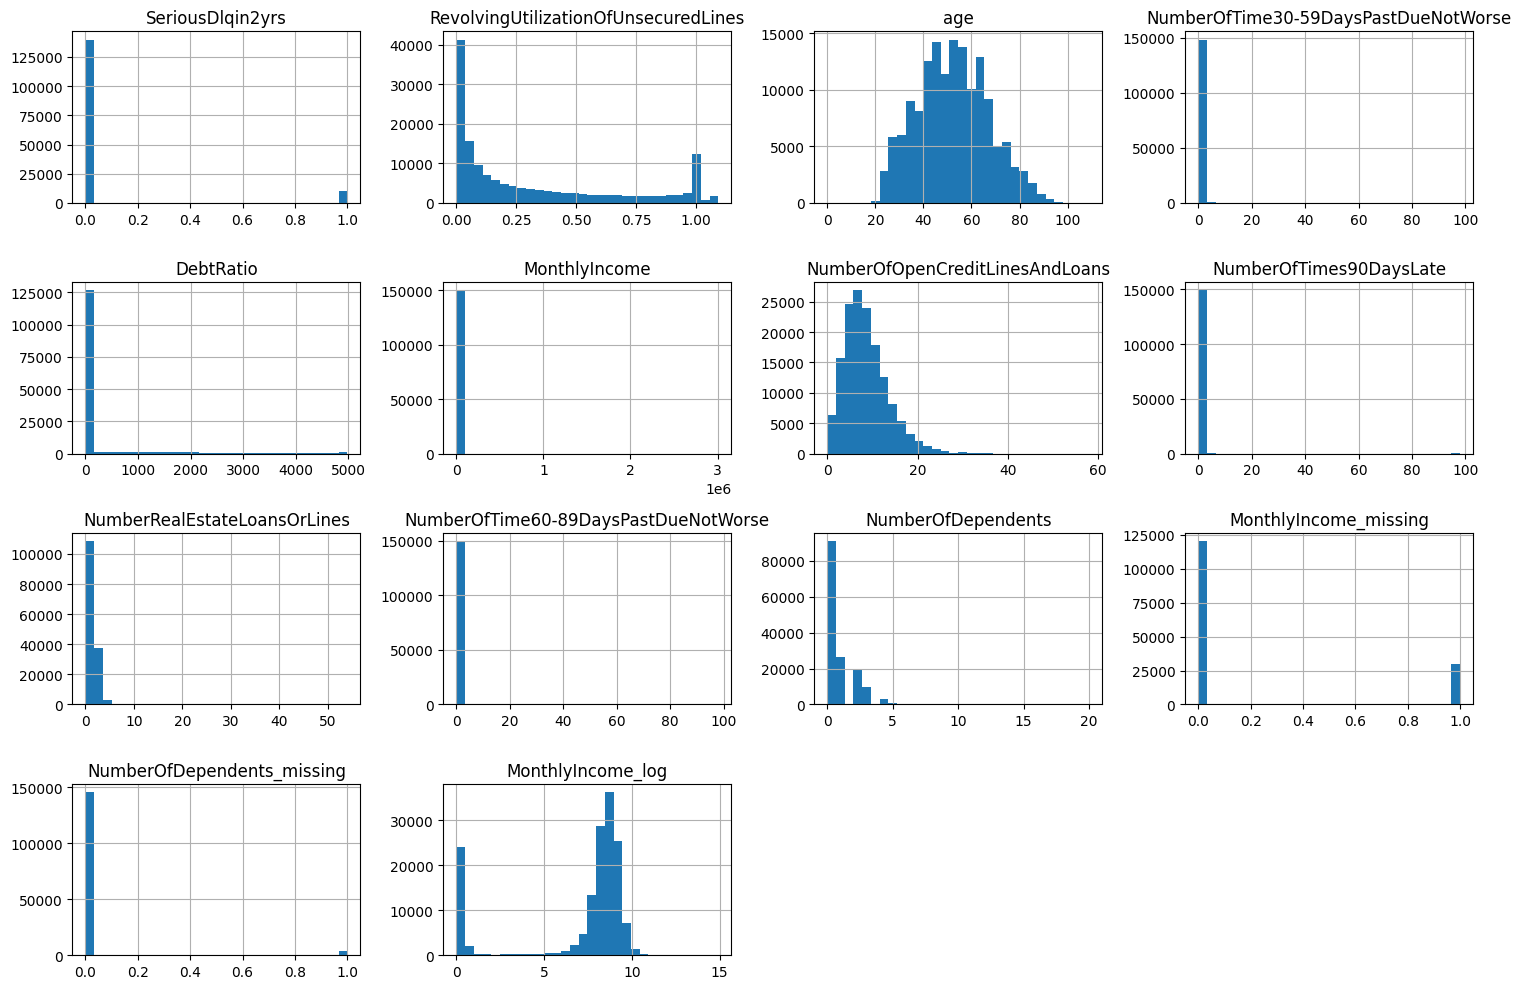

In [71]:
creditdata.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

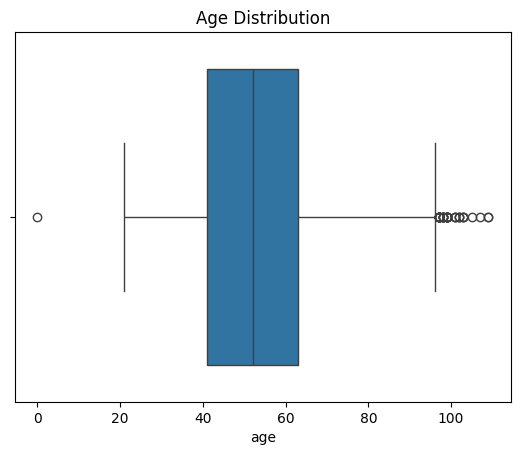

In [17]:
sns.boxplot(x=creditdata['age'])
plt.title("Age Distribution")
plt.show()

We detect outliers in age features age = 0 and age > 100

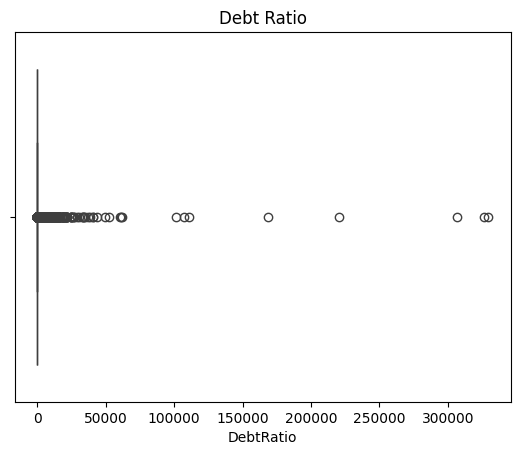

In [18]:
sns.boxplot(x=creditdata['DebtRatio'])
plt.title("Debt Ratio")
plt.show()

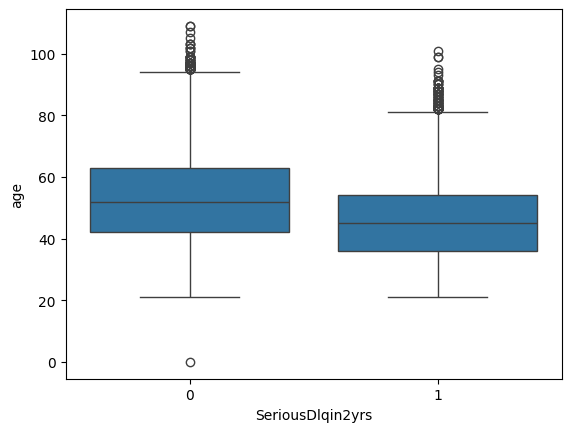

In [19]:
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=creditdata)
plt.show()

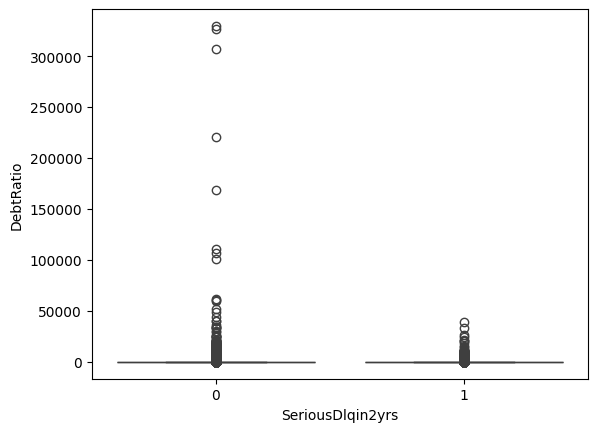

In [20]:
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', data=creditdata)
plt.show()

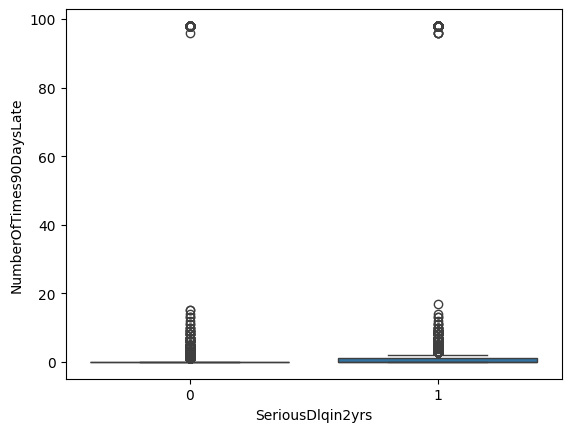

In [21]:
sns.boxplot(x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate', data=creditdata)
plt.show()

# Statistical Tests

In [22]:
from scipy.stats import ttest_ind
stat, p = ttest_ind(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['age'], creditdata[creditdata['SeriousDlqin2yrs'] == 1]['age'])
print(f"T-statistic: {stat}")
print(f"P-value: {p}")

T-statistic: 44.98881115466734
P-value: 0.0


In [23]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['DebtRatio'],creditdata[creditdata['SeriousDlqin2yrs'] == 1]['DebtRatio'])

print("p-value:", p_value)

p-value: 1.4982055203882379e-15


In [24]:
stat, p_value = mannwhitneyu(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['MonthlyIncome'],creditdata[creditdata['SeriousDlqin2yrs'] == 1]['MonthlyIncome'])

print("p-value:", p_value)

p-value: nan


In [25]:
stat, p_value = mannwhitneyu(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['RevolvingUtilizationOfUnsecuredLines'],creditdata[creditdata['SeriousDlqin2yrs'] == 1]['RevolvingUtilizationOfUnsecuredLines'])

print("p-value:", p_value)

p-value: 0.0


In [26]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(creditdata['NumberOfDependents'], creditdata['SeriousDlqin2yrs'])
chi2, p,_,_= chi2_contingency(contingency)

print("p-value:", p)

p-value: 5.545927186738229e-64


In [28]:
creditdata.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)

,SeriousDlqin2yrs
SeriousDlqin2yrs,1.000000
NumberOfTime30-59DaysPastDueNotWorse,0.125587
NumberOfTimes90DaysLate,0.117175
NumberOfTime60-89DaysPastDueNotWorse,0.102261
NumberOfDependents,0.046048
Unnamed: 0,0.002801
RevolvingUtilizationOfUnsecuredLines,-0.001802
NumberRealEstateLoansOrLines,-0.007038
DebtRatio,-0.007602
MonthlyIncome,-0.019746


In [29]:
creditdata['DebtRatio'].skew()
np.log1p(creditdata['DebtRatio']).skew()



np.float64(1.7490132141424464)

In [30]:
creditdata.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [31]:
creditdata['MonthlyIncome_missing'] = creditdata['MonthlyIncome'].isnull().astype(int)

In [32]:
creditdata['MonthlyIncome_missing'].head()

,MonthlyIncome_missing
0,0
1,0
2,0
3,0
4,0


In [33]:
creditdata[creditdata['NumberOfDependents'].isna()]


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN,1
96,97,0,0.542243,48,2,10.0,NaN,2,0,0,0,NaN,1
109,110,0,0.041258,61,0,4739.0,NaN,11,0,4,0,NaN,1
159,160,0,0.000000,63,0,2.0,NaN,4,0,0,0,NaN,1
238,239,0,1.000000,28,0,0.0,NaN,0,0,0,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149826,149827,0,0.027319,71,0,1419.0,NaN,13,0,1,0,NaN,1
149854,149855,0,0.056589,75,0,8.0,NaN,3,0,0,0,NaN,1
149894,149895,0,0.017904,55,0,1058.0,NaN,8,0,1,1,NaN,1
149948,149949,0,0.055530,27,0,10.0,NaN,1,0,0,0,NaN,1


In [34]:
creditdata.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
MonthlyIncome_missing,
0,0.069486
1,0.056137


In [36]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(creditdata['MonthlyIncome_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 67.89295377039625
P-value: 1.7261692959788902e-16


p_value << 0.05 that means there is statistically significant relationship between missing income and default risk.

In [37]:
creditdata['NumberOfDependents'].value_counts()

,count
NumberOfDependents,
0.0,86902
1.0,26316
2.0,19522
3.0,9483
4.0,2862
5.0,746
6.0,158
7.0,51
8.0,24


In [38]:
creditdata['NumberOfDependents_missing'] = creditdata['NumberOfDependents'].isnull().astype(int)

In [39]:
creditdata.groupby('NumberOfDependents_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
NumberOfDependents_missing,
0,0.067410
1,0.045617


In [40]:
contingency_table = pd.crosstab(creditdata['NumberOfDependents_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 28.750364797617962
P-value: 8.233441027500607e-08


The chi-square test shows a statistically significant association between missing values in NumberOfDependents and SeriousDlqin2yrs (p < 0.05). Applicants with missing dependents have a lower observed default rate, suggesting that missingness carries predictive information.

In [41]:
print('Skewness coeficient',creditdata['age'].skew())

Skewness coeficient 0.18899454512676198


In [43]:
creditdata.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0


EDA

In [44]:
creditdata.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing'],
      dtype='object')

In [50]:
creditdata["age_bin"] = pd.cut(creditdata["age"], bins=[20,30,40,50,60,70,100])

creditdata.groupby("age_bin")["SeriousDlqin2yrs"].mean()



/tmp/ipykernel_66963/1677721344.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,SeriousDlqin2yrs
age_bin,
"(20, 30]",0.115646
"(30, 40]",0.098196
"(40, 50]",0.082570
"(50, 60]",0.061742
"(60, 70]",0.034714
"(70, 100]",0.022527


In [51]:
y = creditdata['SeriousDlqin2yrs']
X = creditdata.drop(columns = ['SeriousDlqin2yrs'])

This project compares various classification algorithms to identify the most effective model for predicting customer creditworthiness and minimizing default risk.

In [52]:
from sklearn.ensemble import RandomForestRegressor

features_for_impute = [
    'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents', 'RevolvingUtilizationOfUnsecuredLines'
]
train_income = creditdata[creditdata['MonthlyIncome'].notna()]
test_income = creditdata[creditdata['MonthlyIncome'].isna()]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_income[features_for_impute], train_income['MonthlyIncome'])

predicted_income = rf.predict(test_income[features_for_impute])

creditdata.loc[creditdata['MonthlyIncome'].isnull(), 'MonthlyIncome'] = predicted_income

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

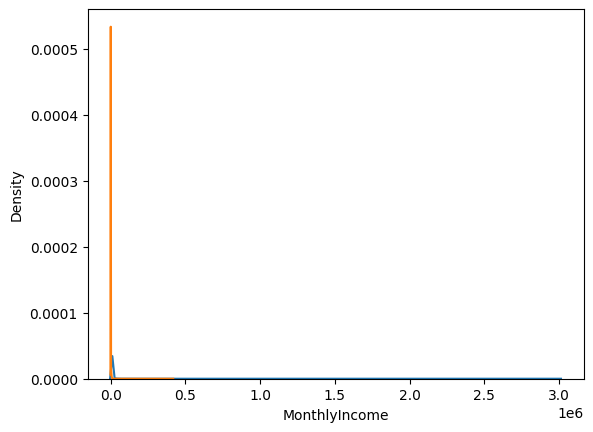

In [53]:
# Compare distributions
sns.kdeplot(train_income['MonthlyIncome'], label='Original')
sns.kdeplot(predicted_income, label='Imputed')

I used Random Forest for imputing MonthlyIncome because it captures non-linear relationships between financial features, is robust to outliers, and requires minimal preprocessing. Since the goal was to generate realistic values rather than perfectly predict income, it provided a strong and stable solution.

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

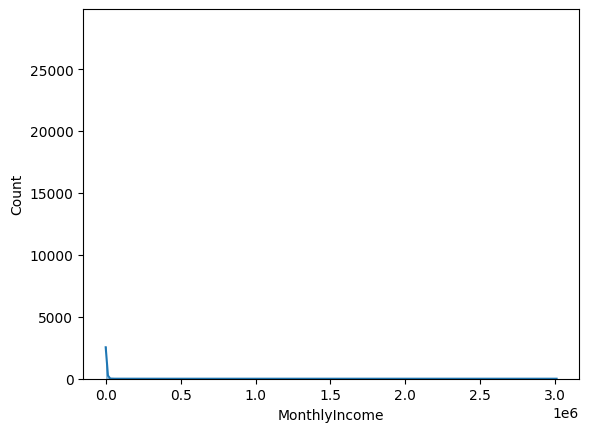

In [54]:
sns.histplot(creditdata['MonthlyIncome'], kde=True)

In [55]:
creditdata['NumberOfDependents'].fillna(creditdata['NumberOfDependents'].median(), inplace=True)

/tmp/ipykernel_66963/3188986091.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [56]:
creditdata['NumberOfDependents'].isna().sum()

np.int64(0)

In [57]:
creditdata['MonthlyIncome'].skew()
creditdata['MonthlyIncome_log'] = np.log1p(creditdata['MonthlyIncome'])

In [58]:
creditdata['MonthlyIncome_log'].skew()

np.float64(-1.4773223164932316)

<Axes: xlabel='MonthlyIncome_log', ylabel='Count'>

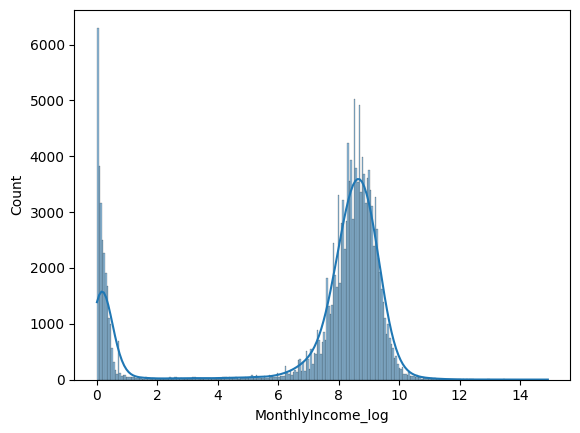

In [59]:
sns.histplot(creditdata['MonthlyIncome_log'], kde=True)

In [60]:
creditdata['MonthlyIncome'].skew()

np.float64(116.93869072211099)

In [61]:
np.log1p(creditdata['MonthlyIncome']).skew()

np.float64(-1.4773223164932316)

In [62]:
creditdata['DebtRatio'] = np.clip(creditdata['DebtRatio'], 0, creditdata['DebtRatio'].quantile(0.99))


<Axes: xlabel='DebtRatio'>

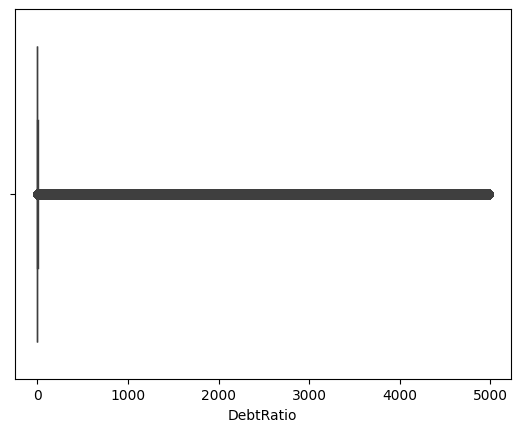

In [63]:
sns.boxplot(x=creditdata['DebtRatio'])

In [64]:
creditdata['RevolvingUtilizationOfUnsecuredLines'] = np.clip(
        creditdata['RevolvingUtilizationOfUnsecuredLines'],
        0,
        creditdata['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
    )

<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines'>

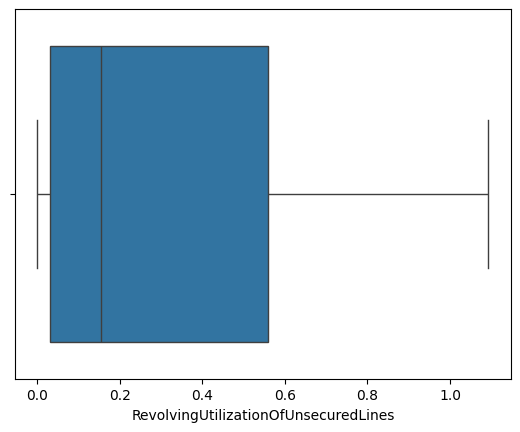

In [65]:
sns.boxplot(x=creditdata['RevolvingUtilizationOfUnsecuredLines'])

Train/Test Split

In [66]:
creditdata.drop(columns=['age_bin'], inplace=True)

In [67]:
def split_data(creditdata):
  X = creditdata.drop(columns=['SeriousDlqin2yrs'])
  y = creditdata['SeriousDlqin2yrs']
  return train_test_split(
      X,
      y,
      test_size=0.2,
      random_state=42
  )
X_train, X_test, y_train, y_test = split_data(creditdata)

Models

In [68]:
models = [
     LogisticRegression(max_iter = 1000),
     SVC(),
     KNeighborsClassifier(),
     RandomForestClassifier(),
     DecisionTreeClassifier(),
     LGBMClassifier(),
     XGBClassifier()
]


Evaluation OF MODELS

In [69]:
def compare_models(models, X_train, X_test, y_train, y_test):
  for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model: {model.__class__.__name__}, Accuracy: {accuracy}")

In [70]:
compare_models(models, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Model: LogisticRegression, Accuracy: 0.9344333333333333
Model: SVC, Accuracy: 0.9348
Model: KNeighborsClassifier, Accuracy: 0.9339
Model: RandomForestClassifier, Accuracy: 0.9366666666666666
Model: DecisionTreeClassifier, Accuracy: 0.8965333333333333
[LightGBM] [Info] Number of positive: 8070, number of negative: 111930
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1234
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.067250 -> initscore=-2.629720
[LightGBM] [Info] Start training from score -2.629720
Model: LGBMClassifier, Accuracy: 0.9380666666666667
Model: XGBClassifier, Accuracy: 0.9361666666666667


Based in this results we can see that the data is imbalanced with number of postive is 8070 and negative is 111930. Accuracy is not the right metric. we will choose AUC-ROC metric because it works well for imbalance.

In [74]:
from sklearn.metrics import roc_auc_score

for model in models:

    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Model: {model.__class__.__name__} AUC: {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Model: LogisticRegression AUC: 0.7770


AttributeError: This 'SVC' has no attribute 'predict_proba'